# Prompt Ablation — Accuracy & Self-Consistency by Prompt Template × Model

Compare **3 prompt templates** (`standard`, `chain_of_thought`, `vigilant`) × **2 models**
(`claude-haiku-4-5-20251001`, `gpt-4o-mini`) at a fixed poison rate of **50 %** (k=5).

Two measurement phases:
1. **Accuracy phase** — temperature=0, `sc_runs=1`, N=50. Hits the cache from notebook 03.
2. **Self-consistency phase** — temperature=0.7, `sc_runs=5`, N_SC=30 (subset).  
   New calls: 3 prompts × 2 models × 30 × 5 = **900 calls** (re-runs are cached).

Attribution:
- Prompt ablation design — Zhou et al. 2024 §2.1 (CoT, vigilant prompting) + Singal et al. 2024 §4 (standard prompt).
- Self-consistency metric — Wang et al. 2022 (cited in Zhou 2024 §2.1); operationalised as output
  stability under passage-order perturbation.

**Set `DRY_RUN = True` to validate wiring (~30 calls), `False` for the full experiment (~900 new calls).**

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DRY_RUN = False  # set True for a quick validation run

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPES    = ["standard", "chain_of_thought", "vigilant"]
POISON_RATE     = 0.5   # fixed for this ablation

# Phase 1 — accuracy (temperature=0, deterministic)
TEMP_ACC        = cfg["models"]["temperature"]        # 0.0
N_ACC           = 5 if DRY_RUN else cfg["evaluation"]["n_examples"]   # 50

# Phase 2 — self-consistency (temperature > 0, multiple runs)
TEMP_SC         = cfg["models"]["temperature_consistency"]            # 0.7
SC_RUNS         = 2 if DRY_RUN else cfg["evaluation"]["self_consistency_runs"]  # 5
N_SC            = 5 if DRY_RUN else cfg["evaluation"]["self_consistency_subset"] # 30

total_acc_calls = len(PROMPT_TYPES) * len(MODELS) * N_ACC
total_sc_calls  = len(PROMPT_TYPES) * len(MODELS) * N_SC * SC_RUNS
print(f"DRY_RUN={DRY_RUN}  POISON_RATE={POISON_RATE}")
print(f"Phase 1 — accuracy:          {len(PROMPT_TYPES)} prompts × {len(MODELS)} models × {N_ACC} examples = {total_acc_calls} calls (cached from nb03)")
print(f"Phase 2 — self-consistency:  {len(PROMPT_TYPES)} prompts × {len(MODELS)} models × {N_SC} examples × {SC_RUNS} runs = {total_sc_calls} new calls")

DRY_RUN=False  POISON_RATE=0.5
Phase 1 — accuracy:          3 prompts × 2 models × 50 examples = 300 calls (cached from nb03)
Phase 2 — self-consistency:  3 prompts × 2 models × 30 examples × 5 runs = 900 new calls


In [11]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import AnthropicClient, OpenAIClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples_acc = all_examples[:N_ACC]
examples_sc  = all_examples[:N_SC]

# Pre-poison at the fixed rate; same seed → same passages as nb03 (guaranteed cache hits)
poisoned_acc = poison_dataset(examples_acc, poison_rate=POISON_RATE, seed=SEED)
poisoned_sc  = poison_dataset(examples_sc,  poison_rate=POISON_RATE, seed=SEED)

print(f"Accuracy pool:          {len(poisoned_acc)} examples")
print(f"Self-consistency pool:  {len(poisoned_sc)} examples")

Accuracy pool:          50 examples
Self-consistency pool:  30 examples


In [12]:
def build_llm(model: str, temperature: float):
    """Instantiate the right LLM client based on model name prefix."""
    if model.startswith("claude"):
        return AnthropicClient(model=model, temperature=temperature, cache_dir=LLM_CACHE)
    return OpenAIClient(model=model, temperature=temperature, cache_dir=LLM_CACHE)


def run_ablation_sweep(examples, prompt_types, models, k, embedder, temperature,
                       distractor_pool, seed, sc_runs=1):
    """Run prompt_types × models sweep; return list of metric dicts."""
    rows = []
    for model_name in models:
        print(f"\n--- Model: {model_name} (temp={temperature}) ---")
        llm = build_llm(model_name, temperature)
        with llm:
            for prompt_type in prompt_types:
                retriever = Retriever(embedder=embedder, k=k)
                metrics = run_scorer(
                    examples=examples,
                    retriever=retriever,
                    llm=llm,
                    prompt_type=prompt_type,
                    distractor_pool_size=distractor_pool,
                    seed=seed,
                    self_consistency_runs=sc_runs,
                )
                rows.append({"model": model_name, "prompt_type": prompt_type, **metrics})
                sc_str = f"  sc={metrics.get('self_consistency', float('nan')):.3f}" if sc_runs > 1 else ""
                print(
                    f"  prompt={prompt_type:15s}  acc={metrics['accuracy']:.3f}"
                    f"  f1={metrics['macro_f1']:.3f}"
                    f"  hall={metrics['hallucination_rate']:.3f}{sc_str}"
                )
    return rows

## Phase 1 — Accuracy Ablation (temperature=0, N=50)

These calls hit the response cache from notebook 03 (same `seed`, same `poison_rate=0.5`, same examples).

In [13]:
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE, device="cpu")

print("Phase 1 — accuracy sweep (poison_rate=0.5, temperature=0) ...")
acc_rows = run_ablation_sweep(
    examples=poisoned_acc,
    prompt_types=PROMPT_TYPES,
    models=MODELS,
    k=K,
    embedder=embedder,
    temperature=TEMP_ACC,
    distractor_pool=DISTRACTOR_POOL,
    seed=SEED,
    sc_runs=1,
)
df_acc = pd.DataFrame(acc_rows)
print(f"\nPhase 1 done. {len(df_acc)} conditions.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Phase 1 — accuracy sweep (poison_rate=0.5, temperature=0) ...

--- Model: claude-haiku-4-5-20251001 (temp=0.0) ---
  prompt=standard         acc=0.680  f1=0.684  hall=0.118
  prompt=chain_of_thought  acc=0.680  f1=0.684  hall=0.118
  prompt=vigilant         acc=0.600  f1=0.603  hall=0.176

--- Model: gpt-4o-mini (temp=0.0) ---
  prompt=standard         acc=0.640  f1=0.645  hall=0.176
  prompt=chain_of_thought  acc=0.560  f1=0.564  hall=0.471
  prompt=vigilant         acc=0.640  f1=0.637  hall=0.118

Phase 1 done. 6 conditions.


## Phase 2 — Self-Consistency (temperature=0.7, N=30, sc_runs=5)

Attribution: Wang et al. 2022 (cited in Zhou 2024 §2.1) — self-consistency decoding operationalised  
as output stability under passage-order perturbation.

In [14]:
print(f"Phase 2 — self-consistency sweep (poison_rate={POISON_RATE}, temp={TEMP_SC}, sc_runs={SC_RUNS}) ...")
sc_rows = run_ablation_sweep(
    examples=poisoned_sc,
    prompt_types=PROMPT_TYPES,
    models=MODELS,
    k=K,
    embedder=embedder,
    temperature=TEMP_SC,
    distractor_pool=DISTRACTOR_POOL,
    seed=SEED,
    sc_runs=SC_RUNS,
)
embedder.close()

df_sc = pd.DataFrame(sc_rows)[["model", "prompt_type", "self_consistency"]]
print(f"\nPhase 2 done. {len(df_sc)} conditions.")

Phase 2 — self-consistency sweep (poison_rate=0.5, temp=0.7, sc_runs=5) ...

--- Model: claude-haiku-4-5-20251001 (temp=0.7) ---
  prompt=standard         acc=0.800  f1=0.803  hall=0.125  sc=0.940


Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.
Attempt 1/4 failed (status=429). Retrying in 5.0s.


  prompt=chain_of_thought  acc=0.733  f1=0.746  hall=0.125  sc=0.960


Attempt 1/4 failed (status=429). Retrying in 5.0s.


  prompt=vigilant         acc=0.767  f1=0.775  hall=0.125  sc=0.913

--- Model: gpt-4o-mini (temp=0.7) ---
  prompt=standard         acc=0.833  f1=0.822  hall=0.125  sc=0.953
  prompt=chain_of_thought  acc=0.867  f1=0.855  hall=0.250  sc=0.933
  prompt=vigilant         acc=0.867  f1=0.859  hall=0.125  sc=0.953

Phase 2 done. 6 conditions.


## Combined Ablation Table

In [15]:
df = df_acc.merge(df_sc, on=["model", "prompt_type"], how="left")

# Short model names for display
df["model_short"] = df["model"].apply(lambda x: x.split("-")[0])

display_cols = ["model", "prompt_type", "accuracy", "macro_f1", "hallucination_rate", "self_consistency"]
table = df[display_cols].copy()
table = table.set_index(["model", "prompt_type"])
table.columns = ["Accuracy", "Macro-F1", "Hallucination Rate", "Self-Consistency"]
table.index = table.index.map(lambda x: (x[0].split("-")[0], x[1]))

print(f"=== Prompt Ablation Table (poison_rate={POISON_RATE}, k={K}) ===")
print(table.to_string(float_format="{:.3f}".format))

=== Prompt Ablation Table (poison_rate=0.5, k=5) ===
                         Accuracy  Macro-F1  Hallucination Rate  Self-Consistency
model  prompt_type                                                               
claude standard             0.680     0.684               0.118             0.940
       chain_of_thought     0.680     0.684               0.118             0.960
       vigilant             0.600     0.603               0.176             0.913
gpt    standard             0.640     0.645               0.176             0.953
       chain_of_thought     0.560     0.564               0.471             0.933
       vigilant             0.640     0.637               0.118             0.953


In [16]:
# Pivot: rows = prompt_type, columns = model
pivot_acc = df.pivot_table(
    index="prompt_type", columns="model_short", values="accuracy"
)
pivot_f1 = df.pivot_table(
    index="prompt_type", columns="model_short", values="macro_f1"
)
pivot_hall = df.pivot_table(
    index="prompt_type", columns="model_short", values="hallucination_rate"
)
pivot_sc = df.pivot_table(
    index="prompt_type", columns="model_short", values="self_consistency"
)

print("=== Accuracy (↑ better) ===")
print(pivot_acc.to_string(float_format="{:.3f}".format))
print("\n=== Macro-F1 (↑ better) ===")
print(pivot_f1.to_string(float_format="{:.3f}".format))
print("\n=== Hallucination Rate (↓ better) ===")
print(pivot_hall.to_string(float_format="{:.3f}".format))
print("\n=== Self-Consistency (↑ better) ===")
print(pivot_sc.to_string(float_format="{:.3f}".format))

=== Accuracy (↑ better) ===
model_short       claude   gpt
prompt_type                   
chain_of_thought   0.680 0.560
standard           0.680 0.640
vigilant           0.600 0.640

=== Macro-F1 (↑ better) ===
model_short       claude   gpt
prompt_type                   
chain_of_thought   0.684 0.564
standard           0.684 0.645
vigilant           0.603 0.637

=== Hallucination Rate (↓ better) ===
model_short       claude   gpt
prompt_type                   
chain_of_thought   0.118 0.471
standard           0.118 0.176
vigilant           0.176 0.118

=== Self-Consistency (↑ better) ===
model_short       claude   gpt
prompt_type                   
chain_of_thought   0.960 0.933
standard           0.940 0.953
vigilant           0.913 0.953


## Plots

Saved → figures/04_prompt_ablation.png


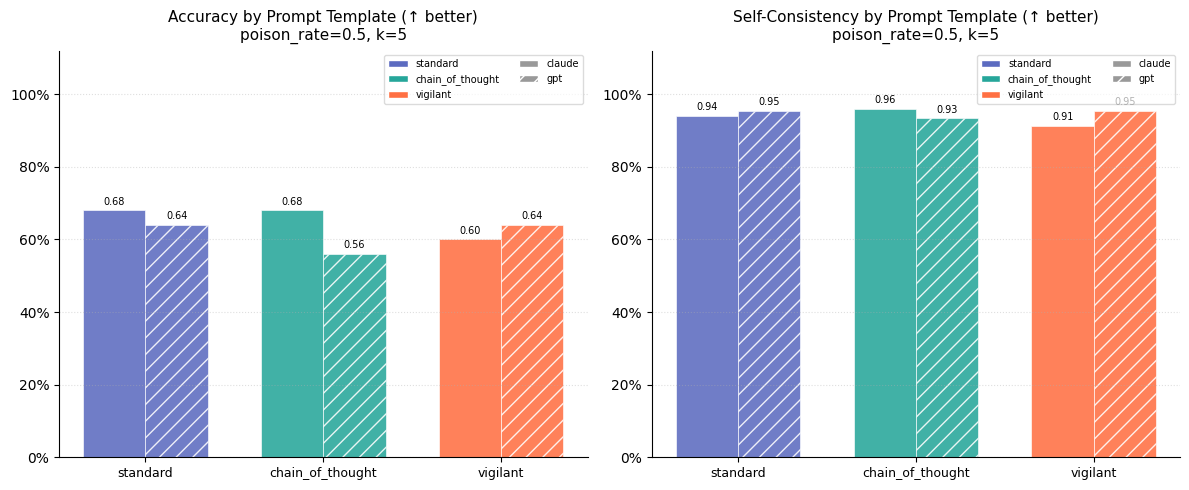

In [17]:
# Grouped bar chart: accuracy by prompt_type, grouped by model
# Same colour palette as nb03
PROMPT_COLORS = {
    "standard":         "#5C6BC0",
    "chain_of_thought": "#26A69A",
    "vigilant":         "#FF7043",
}
MODEL_HATCH = {m: ("" if i == 0 else "//") for i, m in enumerate(MODELS)}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, (metric, title, arrow) in zip(
    axes,
    [("accuracy", "Accuracy", "↑"), ("self_consistency", "Self-Consistency", "↑")],
):
    x = np.arange(len(PROMPT_TYPES))
    bar_width = 0.35

    for i, model in enumerate(MODELS):
        subset = df[df["model"] == model].set_index("prompt_type")
        vals = [subset.loc[p, metric] if p in subset.index else 0 for p in PROMPT_TYPES]
        short = model.split("-")[0]
        bars = ax.bar(
            x + i * bar_width, vals, bar_width,
            label=short,
            color=[PROMPT_COLORS[p] for p in PROMPT_TYPES],
            hatch=MODEL_HATCH[model],
            edgecolor="white",
            linewidth=0.5,
            alpha=0.88,
        )
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7,
            )

    ax.set_title(f"{title} by Prompt Template ({arrow} better)\npoison_rate={POISON_RATE}, k={K}",
                 fontsize=11, pad=8)
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels(PROMPT_TYPES, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    # Legend: model linestyle (hatch)
    import matplotlib.patches as mpatches
    model_handles = [
        mpatches.Patch(facecolor="#999", hatch=MODEL_HATCH[m], label=m.split("-")[0],
                       edgecolor="white")
        for m in MODELS
    ]
    prompt_handles = [
        mpatches.Patch(facecolor=PROMPT_COLORS[p], label=p, edgecolor="white")
        for p in PROMPT_TYPES
    ]
    ax.legend(handles=prompt_handles + model_handles, fontsize=7, loc="upper right",
              ncol=2, framealpha=0.7)

plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
if not DRY_RUN:
    plt.savefig("../figures/04_prompt_ablation.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/04_prompt_ablation.png")
plt.show()

Saved → figures/04_hallucination_heatmap.png


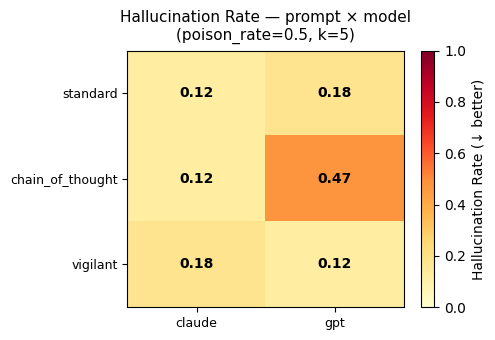

In [18]:
# Hallucination rate heatmap (prompt × model)
fig, ax = plt.subplots(figsize=(5, 3.5))
heat_data = df.pivot_table(
    index="prompt_type", columns="model_short", values="hallucination_rate"
)
# Reorder rows to match PROMPT_TYPES order
heat_data = heat_data.reindex(PROMPT_TYPES)

im = ax.imshow(heat_data.values, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Hallucination Rate (↓ better)")

ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns, fontsize=9)
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index, fontsize=9)
ax.set_title(f"Hallucination Rate — prompt × model\n(poison_rate={POISON_RATE}, k={K})",
             fontsize=11, pad=8)

for i, row in enumerate(heat_data.values):
    for j, val in enumerate(row):
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="black" if val < 0.6 else "white", fontsize=10, fontweight="bold")

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/04_hallucination_heatmap.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/04_hallucination_heatmap.png")
plt.show()

## Key Findings

**Accuracy** (`poison_rate=0.5`, `k=5`, N=50, temperature=0):

- `standard` and `chain_of_thought` tie as the best prompts for Claude (acc=0.680); `vigilant` costs −8 pp.
- For GPT, `vigilant` matches `standard` (0.640) while `chain_of_thought` is the worst (0.560).
- Claude outperforms GPT on every prompt under 50 % poisoning.

**Hallucination Rate** (fraction of NOT ENOUGH INFO predicted as SUPPORTS/REFUTES — ↓ better):

- **GPT + `chain_of_thought` is the worst condition by far** (0.471): step-by-step reasoning amplifies
  overconfidence when poisoned passages dominate — consistent with nb03.
- `vigilant` effectively suppresses GPT hallucination (0.118), confirming its role as a poisoning
  defence (Zhou et al. 2024 §2.1 / §3).
- Claude is stable across all prompts (0.118–0.176), less sensitive to prompt choice.

**Self-Consistency** (temperature=0.7, sc_runs=5, N=30 — ↑ better):

- All conditions cluster tightly between 0.913 and 0.960: both models are robust to passage-order
  perturbation at temp=0.7.
- Claude/`chain_of_thought` is paradoxically the most consistent (0.960) despite not being the most
  accurate — reasoning steps may anchor the output even under shuffle.
- `vigilant` shows the lowest consistency for Claude (0.913), suggesting the consistency-check step
  is itself sensitive to passage order.

**Summary**: Under 50 % poisoning, `standard` offers the best accuracy–hallucination trade-off for
both models. `chain_of_thought` is risky for GPT (high hallucination). `vigilant` is the best
hallucination defence for GPT but at a consistency cost for Claude.

Attribution:
- CoT prompting as a robustness technique — Zhou et al. 2024 §2.1.
- Vigilant prompting as a poisoning defence — Zhou et al. 2024 §2.1 / §3.
- Standard prompt format — Singal et al. 2024 §4, Figure 5.
- Self-consistency metric — Wang et al. 2022 (cited in Zhou 2024 §2.1).